In [1]:
from funs import *

# Data load

In [2]:
data = [
        {'name': 'WT', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/WT/foci_filtered/foci_aggregation.csv"},
        {'name': 'WT + NC', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/WT_NC/foci_filtered/foci_aggregation.csv"},
        {'name': 'WT + Apt.3', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/WT_APT3/foci_filtered/foci_aggregation.csv"},
        {'name': 'MGS3', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/MGS3/foci_filtered/foci_aggregation.csv"},
        {'name': 'MGS3 + NC', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/MGS3_NC/foci_filtered/foci_aggregation.csv"},
        {'name': 'MGS3 + Apt.3', 'path': "/mnt/c/users/helen/Desktop/Ayriscan/MGS3_APT3/foci_filtered/foci_aggregation.csv"},
    ]

labels = [df['name'] for df in data]
print(labels)

['WT', 'WT + NC', 'WT + Apt.3', 'MGS3', 'MGS3 + NC', 'MGS3 + Apt.3']


In [3]:
dfs = []
for item in data:
        p = item["path"]
        df = pd.read_csv(p)
        dfs.append(df)

N_files = len(dfs)
print(f"Loaded {N_files} dataframes.")

Loaded 6 dataframes.


# PCA analysis

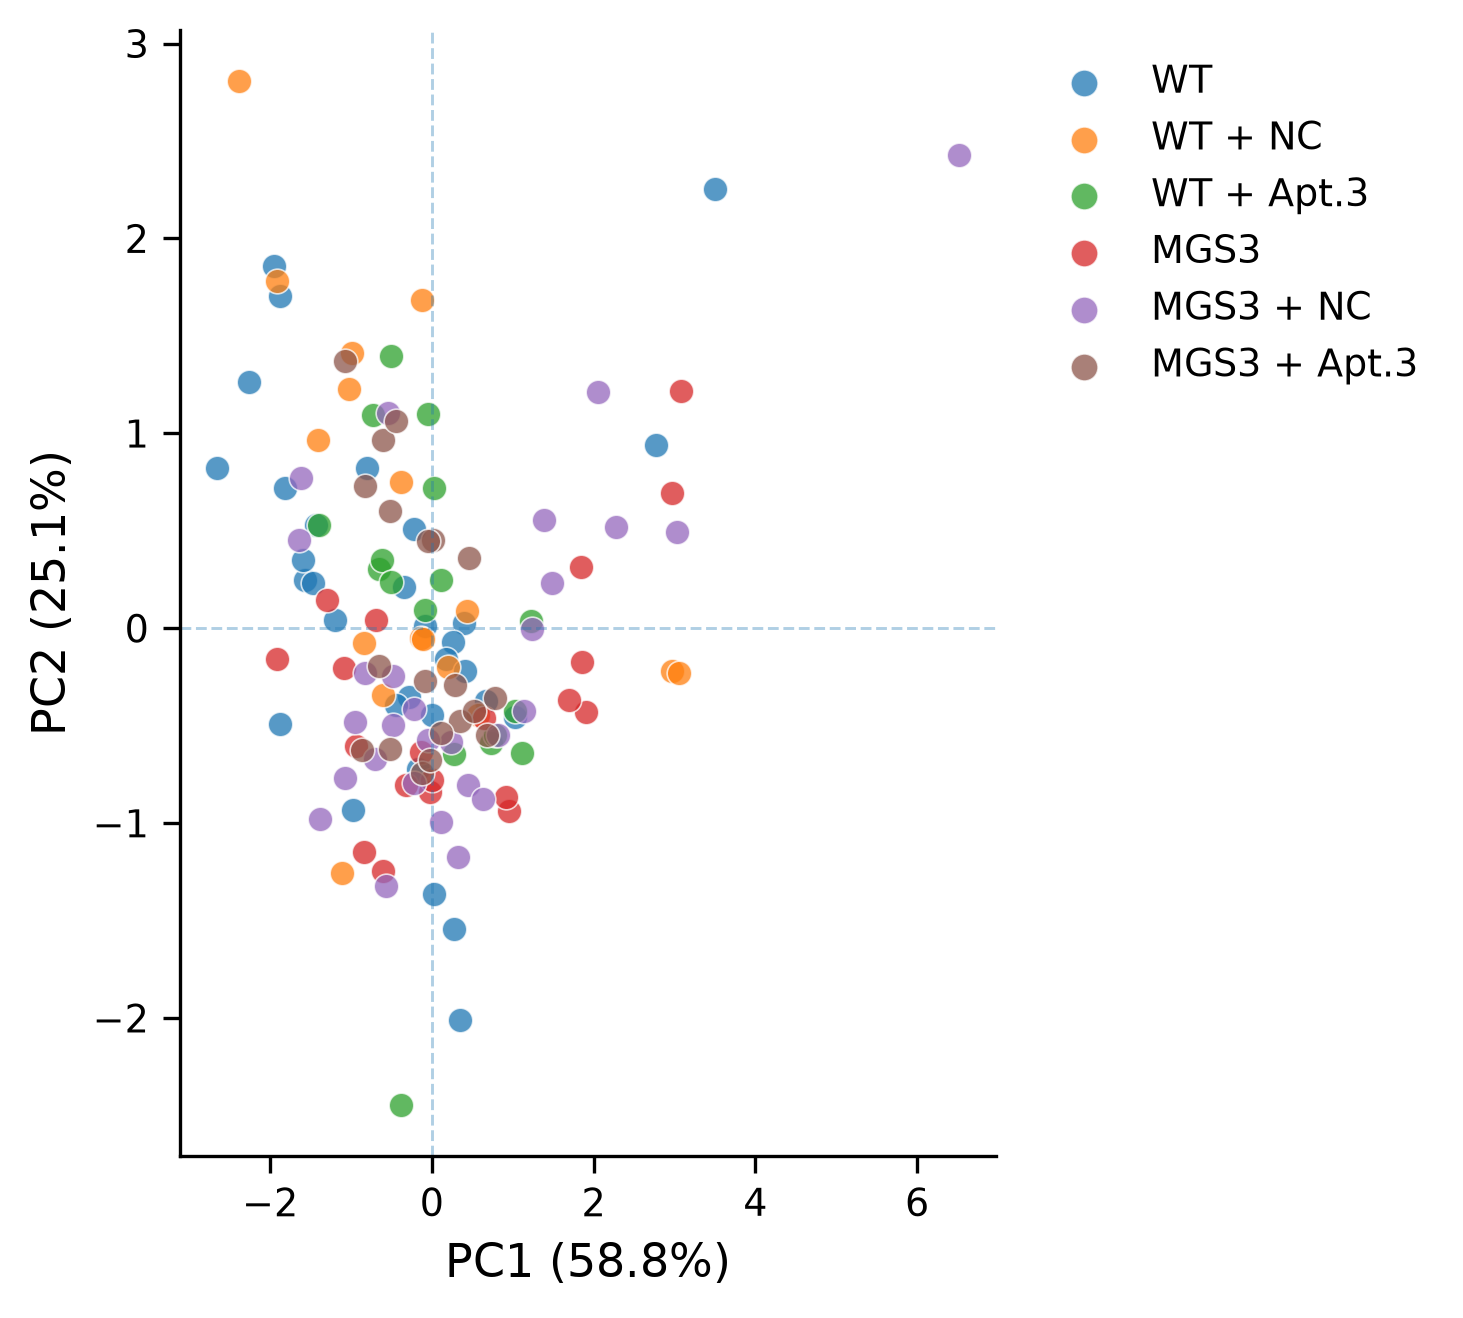

In [4]:
pca_df, pca, fig, ax = pca_from_dataframes(
    df_list=dfs,
    labels=labels,
    columns=[
        "sigma_nm_mean",
        "foci_MFI_mean",
        "n_foci"
    ]
)

# PCs explanation

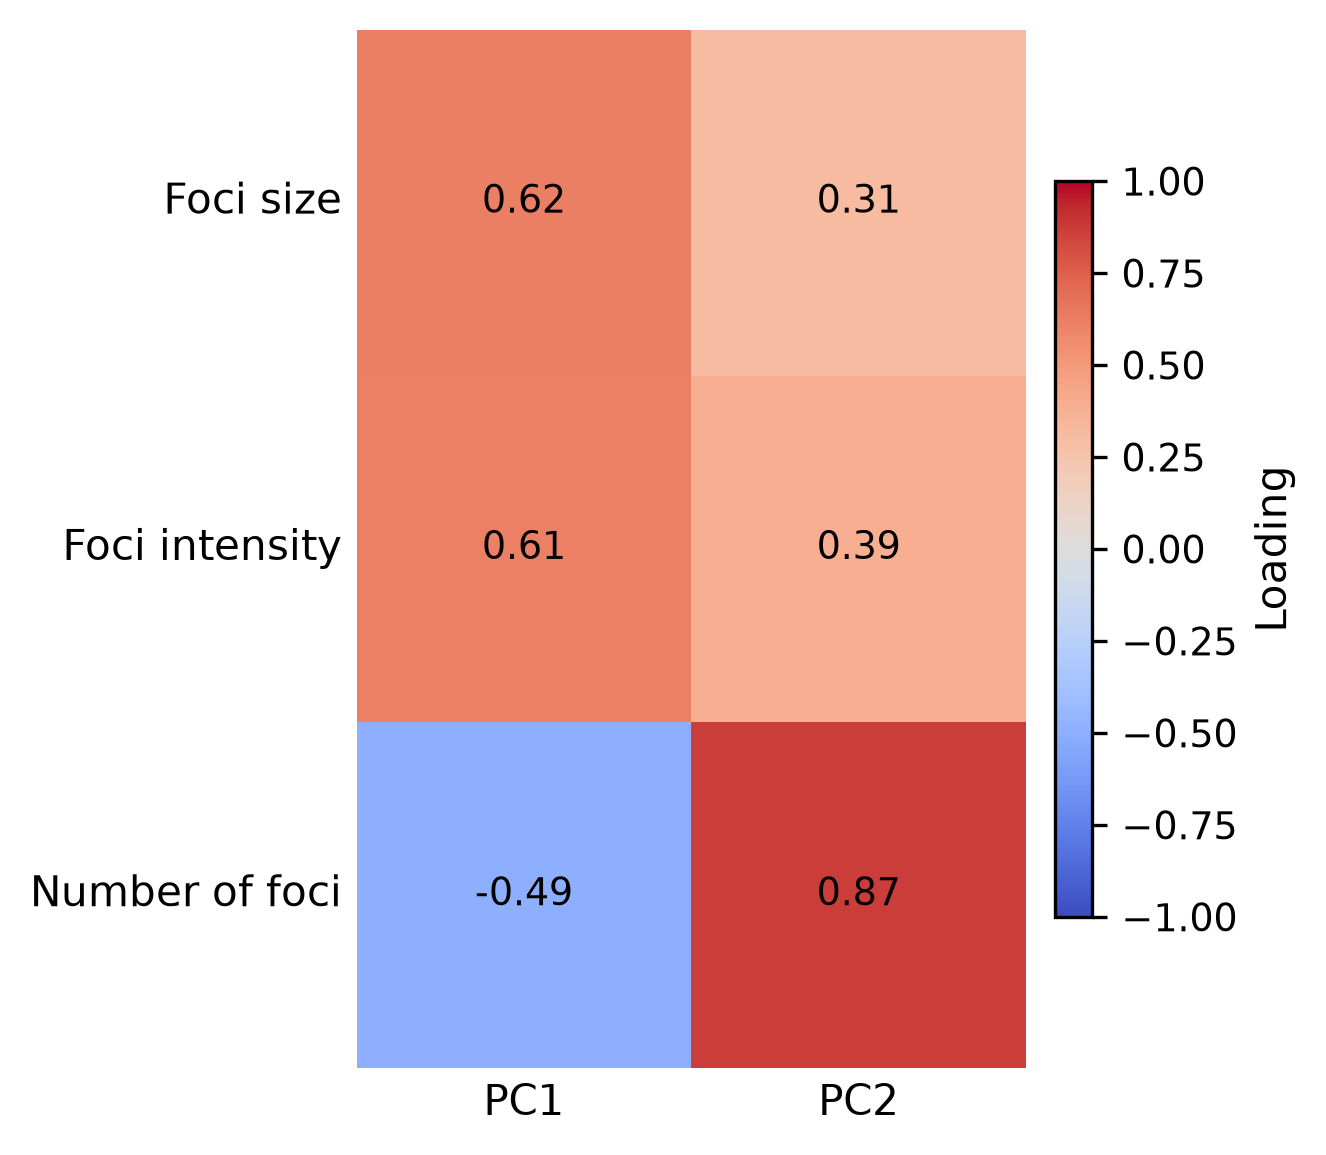

In [6]:
feature_names = {
    "Foci size": "sigma_nm_mean",
    "Foci intensity": "foci_MFI_mean",
    "Number of foci": "n_foci"
}

loadings, fig, ax = plot_pca_loadings(
    pca,
    feature_names
)

# Find center of mass

In [7]:
distances, centroids = pca_centroid_distances(
    pca_df,
    reference="WT"
)

print(distances)

sample
MGS3            0.945623
MGS3 + Apt.3    0.308105
MGS3 + NC       0.855653
WT              0.000000
WT + Apt.3      0.450797
WT + NC         0.416262
Name: distance_from_WT, dtype: float64


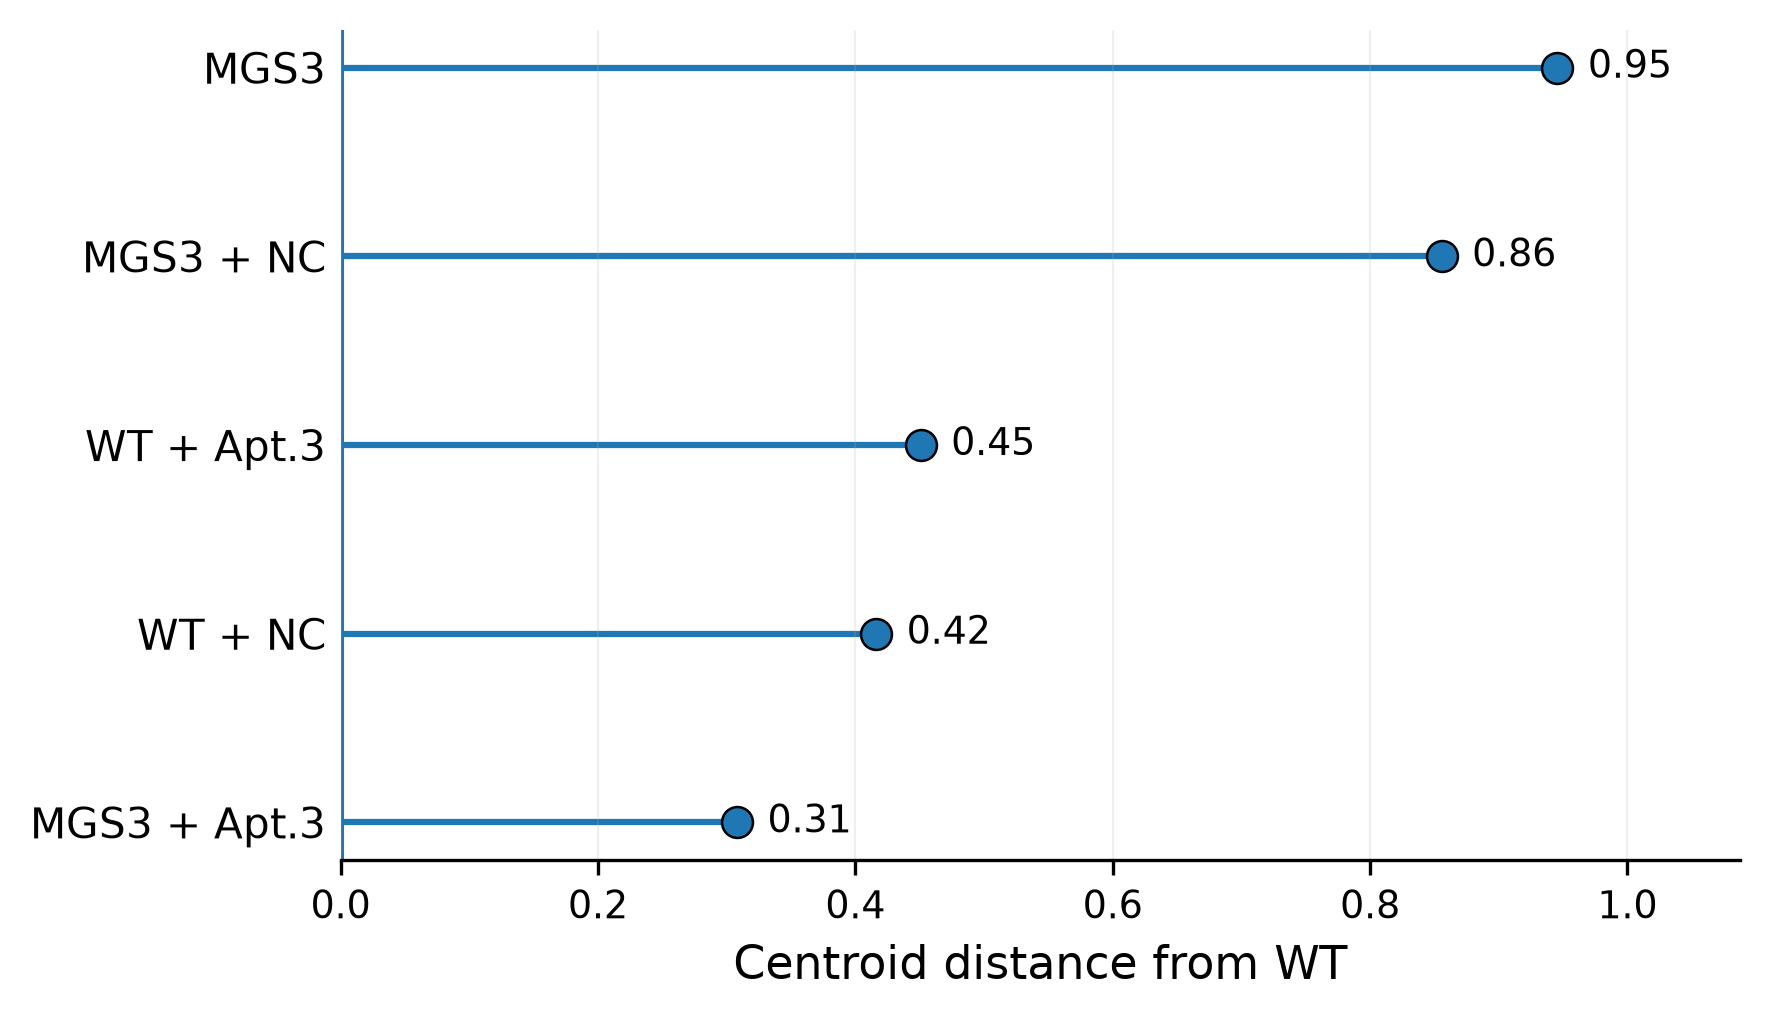

In [8]:
fig, ax = plot_pca_centroid_distances(
    distances,
    reference="WT"
)

# Statistics Permanova

In [16]:
from itertools import combinations

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova
from statsmodels.stats.multitest import multipletests


def pairwise_permanova(
    dfs,
    data,
    columns,
    permutations=9999,
    correction="fdr_bh"
):
    """
    Pairwise PERMANOVA between all samples.

    Parameters
    ----------
    dfs : list[pd.DataFrame]
        DataFrames in the same order as `data`.

    data : list[dict]
        Sample information containing at least:
        {"name": sample_name, "path": path}

    columns : list[str]
        Variables used for the analysis.

    permutations : int
        Number of permutations.

    correction : str
        Multiple-testing correction method.
        Examples: "fdr_bh", "holm", "bonferroni".

    Returns
    -------
    results : pd.DataFrame
        Pairwise PERMANOVA results.
    """

    # --------------------------------
    # Combine all samples
    # --------------------------------

    combined = []

    for df, sample in zip(dfs, data):

        tmp = df[columns].copy()
        tmp["sample"] = sample["name"]

        combined.append(tmp)

    df_all = pd.concat(
        combined,
        ignore_index=True
    )

    df_all = (
        df_all
        .dropna(subset=columns)
        .reset_index(drop=True)
    )

    sample_names = [
        sample["name"]
        for sample in data
    ]

    results = []

    # --------------------------------
    # All pairwise comparisons
    # --------------------------------

    for group1, group2 in combinations(sample_names, 2):

        subset = df_all[
            df_all["sample"].isin([group1, group2])
        ].copy()

        # Standardize variables
        X = StandardScaler().fit_transform(
            subset[columns]
        )

        # Euclidean distance matrix
        distance_matrix = squareform(
            pdist(X, metric="euclidean")
        )

        dm = DistanceMatrix(distance_matrix)

        # PERMANOVA
        result = permanova(
            dm,
            grouping=subset["sample"].to_numpy(),
            permutations=permutations
        )

        results.append({
            "group1": group1,
            "group2": group2,
            "n1": (subset["sample"] == group1).sum(),
            "n2": (subset["sample"] == group2).sum(),
            "pseudo_F": result["test statistic"],
            "p_value": result["p-value"]
        })

    results = pd.DataFrame(results)

    # --------------------------------
    # Multiple-testing correction
    # --------------------------------

    reject, p_adj, _, _ = multipletests(
        results["p_value"],
        method=correction
    )

    results["p_adj"] = p_adj
    results["significant"] = reject

    return results

In [17]:
columns = [
    "sigma_nm_mean",
    "foci_MFI_mean",
    "n_foci"
]

stats = pairwise_permanova(
    dfs,
    data,
    columns,
    permutations=9999
)

print(stats)

        group1        group2  n1  n2  pseudo_F  p_value     p_adj  significant
0           WT       WT + NC  31  17  0.730871   0.5219  0.559179        False
1           WT    WT + Apt.3  31  17  1.481898   0.2247  0.337050        False
2           WT          MGS3  31  20  4.959772   0.0081  0.040500         True
3           WT     MGS3 + NC  31  28  3.510696   0.0270  0.101250        False
4           WT  MGS3 + Apt.3  31  20  0.522935   0.6553  0.655300        False
5      WT + NC    WT + Apt.3  17  17  2.562060   0.0481  0.144300        False
6      WT + NC          MGS3  17  20  2.662401   0.0725  0.181250        False
7      WT + NC     MGS3 + NC  17  28  2.292879   0.0974  0.195187        False
8      WT + NC  MGS3 + Apt.3  17  20  1.241689   0.3102  0.410750        False
9   WT + Apt.3          MGS3  17  20  5.465138   0.0026  0.039000         True
10  WT + Apt.3     MGS3 + NC  17  28  2.153918   0.1041  0.195187        False
11  WT + Apt.3  MGS3 + Apt.3  17  20  1.155095   0.3